In [79]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

df = pd.read_csv('AIML Dataset.csv')
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [81]:
print('Missing Values (NA)')
print(df.isna().sum())
print('\nMissing Values (NULL)')
print(df.isnull().sum())
print('\nDuplicate Values')
print(df.duplicated().sum())

Missing Values (NA)
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Missing Values (NULL)
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Duplicate Values
0


In [82]:
# Calculate fraud cases
print('Total Cases:')
print(len(df))
print('\nTotal Fraud Cases:')
print((df['isFraud'].value_counts())[1])
print('\nPercentage Of Fraud Cases:')
print((((df['isFraud'].value_counts(normalize=True))[1])*100).round(3), "%")

Total Cases:
6362620

Total Fraud Cases:
8213

Percentage Of Fraud Cases:
0.129 %


In [83]:
# Total flagged fraud cases
print('Total Flagged Fraud Cases:')
print((df['isFlaggedFraud'].value_counts()))

Total Flagged Fraud Cases:
isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64


In [84]:
# Visualize transaction types
print('Transaction Types:')
print(df['type'].value_counts())

Transaction Types:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


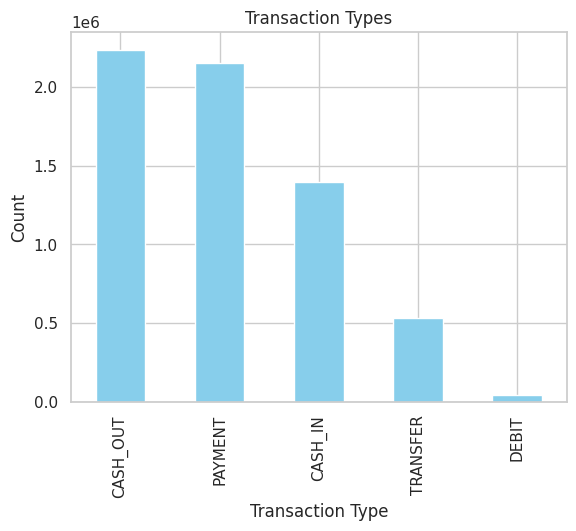

In [85]:
df['type'].value_counts().plot(kind='bar', title='Transaction Types', color='skyblue')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()

In [86]:
# Group by transaction type and fraud or not cases
df_grouped = df.groupby(['type', 'isFraud']).size().unstack()
df_grouped

isFraud,0,1
type,,
CASH_IN,1399284.0,NaN
CASH_OUT,2233384.0,4116.0
DEBIT,41432.0,NaN
PAYMENT,2151495.0,NaN
TRANSFER,528812.0,4097.0


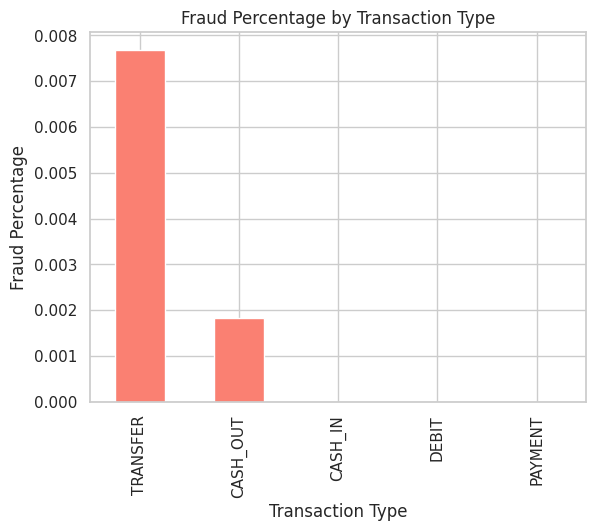

In [87]:
fraud_by_type = df.groupby('type')['isFraud'].mean().sort_values(ascending=False)
fraud_by_type.plot(kind='bar', title='Fraud Percentage by Transaction Type', color='salmon')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Percentage')
plt.show()

In [88]:
# Explore `amount` column statistics
print('Amount Statistics:')
print(df['amount'].describe().astype(int))

Amount Statistics:
count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64


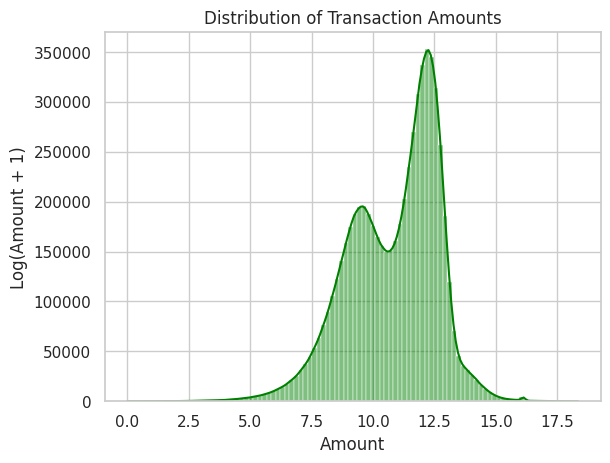

In [89]:
sns.histplot(np.log1p(df['amount']), kde=True, color='green', bins=100)
plt.xlabel('Amount')
plt.ylabel('Log(Amount + 1)')
plt.title('Distribution of Transaction Amounts')
plt.show()

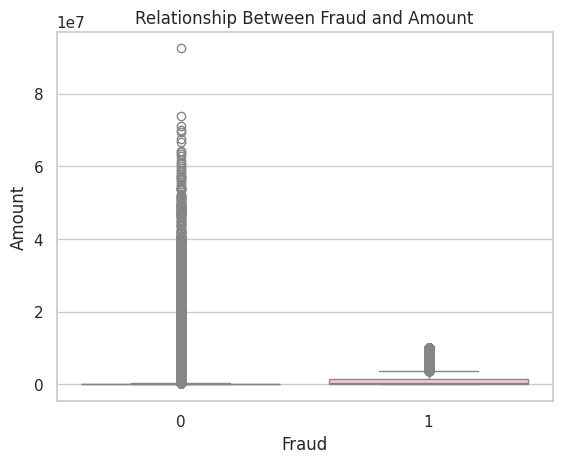

In [90]:
# Find the relationship between fraud cases and `amount` column
sns.boxplot(x='isFraud', y='amount', data=df, color='pink')
plt.xlabel('Fraud')
plt.ylabel('Amount')
plt.title('Relationship Between Fraud and Amount')
plt.show()

In [91]:
# Find balance difference
df['balanceDiffOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
print('Orig Balance Mean Difference')
print(df['balanceDiffOrig'].mean())

df['balanceDiffDest'] = df['oldbalanceDest'] - df['newbalanceDest']
print('\nDest Balance Mean Difference')
print(df['balanceDiffDest'].mean())

Orig Balance Mean Difference
-21230.564504102087

Dest Balance Mean Difference
-124294.73168228011


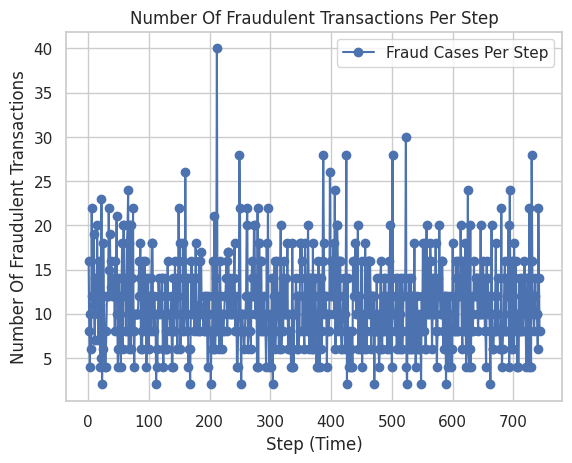

In [92]:
frauds_per_step = df[df['isFraud'] == 1]['step'].value_counts().sort_index()
plt.plot(frauds_per_step.index, frauds_per_step.values, label='Fraud Cases Per Step', marker='o')
plt.xlabel('Step (Time)')
plt.ylabel('Number Of Fraudulent Transactions')
plt.title('Number Of Fraudulent Transactions Per Step')
plt.grid(True)
plt.legend()
plt.show()

In [93]:
df.drop(columns='step',inplace=True)

In [94]:
# Top Senders
top_senders = df['nameOrig'].value_counts().head(10)
print('Top Senders:')
print(top_senders)

Top Senders:
nameOrig
C1530544995    3
C545315117     3
C724452879     3
C1784010646    3
C1677795071    3
C1462946854    3
C1065307291    3
C1999539787    3
C2098525306    3
C400299098     3
Name: count, dtype: int64


In [95]:
# Top Receivers
top_receivers = df['nameDest'].value_counts().head(10)
print('\nTop Receivers:')
print(top_receivers)


Top Receivers:
nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C1789550256     99
C451111351      99
C1360767589     98
C1023714065     97
Name: count, dtype: int64


In [96]:
# Fraud Cases Users
fraud_users = df[df['isFraud'] == 1]['nameOrig'].value_counts().head(10)
print('\nFraud Cases Users:')
print(fraud_users)


Fraud Cases Users:
nameOrig
C1280323807    1
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C1039979813    1
C2089752665    1
C1614818636    1
C40604503      1
C1970706589    1
Name: count, dtype: int64


In [97]:
fraud_types = df[df['isFraud'] == 1]['type'].value_counts()
print('\nFraud Types:')
print(fraud_types)


Fraud Types:
type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64


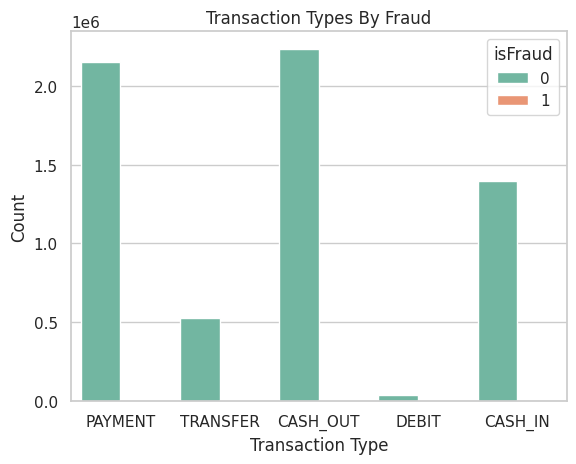

In [98]:
sns.countplot(data=df, x='type', hue='isFraud', palette='Set2')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.title('Transaction Types By Fraud')
plt.show()

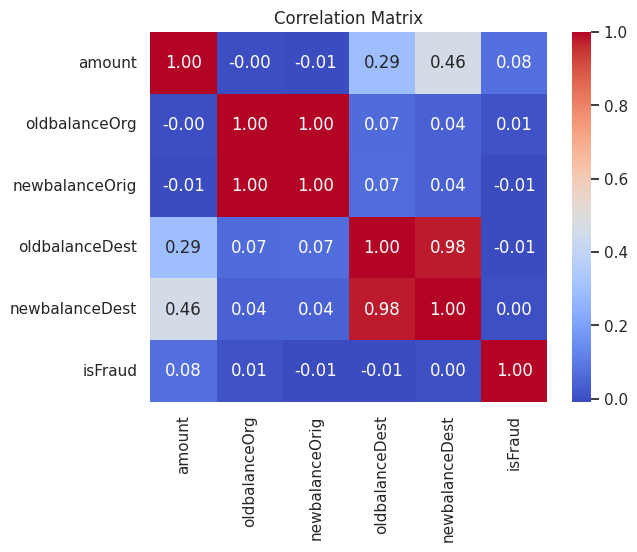

In [99]:
corr = df[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [100]:
zero_after_transfer = df[
    (df['oldbalanceOrg'] > 0) &
    (df['newbalanceOrig'] == 0) &
    (df['type'].isin(['TRANSFER', 'CASH_OUT']))
]
len(zero_after_transfer)

1188074

In [101]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [102]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [103]:
df.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'], inplace=True)

In [104]:
df.columns

Index(['type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFraud', 'balanceDiffOrig', 'balanceDiffDest'],
      dtype='object')

In [105]:
categorical = ['type']
numerical = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
y = df['isFraud']
X = df.drop(columns='isFraud')

# Drop rows where the target variable 'isFraud' is NaN
df.dropna(subset=['isFraud'], inplace=True)
y = df['isFraud']
X = df.drop(columns='isFraud')

In [106]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [107]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical),
        ('cat', OneHotEncoder(drop='first'), categorical)
    ],
    remainder='drop'
  )

In [108]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000))
])

In [109]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [110]:
y_pred = pipeline.predict(X_test)

In [111]:
class_report = classification_report(y_test, y_pred)
print(class_report)

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1270881
           1       0.02      0.94      0.04      1643

    accuracy                           0.95   1272524
   macro avg       0.51      0.94      0.51   1272524
weighted avg       1.00      0.95      0.97   1272524



In [112]:
print(confusion_matrix(y_test, y_pred))

[[1202380   68501]
 [     93    1550]]


In [113]:
pipeline.score(X_test, y_test)

0.9460961050636373

In [114]:
import joblib

joblib.dump(pipeline, 'fraud_detection_model.pkl')

['fraud_detection_model.pkl']